# PyFuga quickstart

This notebook introduces key aspects of PyFuga: the main inputs and outputs, atmospheric-stability effects, and the influence of spectral-grid refinement. Fuga was developed at DTU by Søren Ott and colleagues over several years, and is now available as open-source software in Python.

Suggested reading path:

- Core quickstart: installation, first LUT generation, and first wake-deficit visualisation.
- Stability and scaling: MO-based behaviour and practical scaling of LUT output.
- Spectral-grid sensitivity: impact of ```nkz0``` and ```nbeta``` on accuracy and smoothness.

For readers who want to go deeper into the derivation and assumptions, see the theory pages on [introduction](../theory/introduction.html), [governing equations](../theory/governing_equations.html), [linearisation](../theory/linearisation.html), [mixed-spectral formulation](../theory/mixed_spectral.html), and [numerics](../theory/numerics.html).

## Installation and quick run

For installation instructions, please see the [installation guide](../user_guide/installation.html).

After installation we will create the first lookup table, which is a scaled wake deficit that can be used, with the proper scaling, to estimate wind-turbine wake deficits for many different wind speeds. We start with neutral conditions.

In [1]:
from pyfuga import get_luts

In [2]:
luts = get_luts(
    folder="luts_different_zeta0s_and_nkz0",  # Path where all files (intermediate and final) are stored
    zeta0=0.0,  # Stability parameter, 0 for neutral conditions
    nkz0=8,  # Number of kz0 per decade. Total number of kz0 = 9 * nkz0 - (nkz0-1)
    nbeta=16,  # Number of beta angles. Total number of beta angles = nbeta + 1
    diameter=80,  # Wind turbine diameter [m]
    zhub=70,  # Wind turbine hub height [m]
    z0=1e-4,  # Roughness length [m]
    zi=400,  # Inversion height [m]
    zlow=70,  # Lower height of output domain. If zlow=zhigh=zhub: single layer at hub height
    zhigh=70,  # Upper height of output domain. If zlow=zhigh=zhub: single layer at hub height
    lut_vars=["UL"],  # Any combination of ['UL', 'UT', 'VL', 'VT', 'WL', 'WT', 'PL', 'PT']
    nx=2048,  # Number of points in LUT (U direction)
    ny=512,  # Number of points in LUT (V direction). Note only one half of the domain is stored
    dx=20.0,  # Grid resolution of LUT in longitudinal direction x [m]
    dy=5.0,  # Grid resolution of LUT in lateral direction y [m]
    jit=True,  # If True (default), some slow functions are just-in-time compiled
    n_cpu=None,  # Number of CPUs for parallelization, None means all available CPUs
)

JIT compiled in 0.008246183395385742s


```luts``` is stored as a NetCDF file containing the two- or three-dimensional deficit domain and relevant variables, including ```['UL', 'UT', 'VL', 'VT', 'WL', 'WT', 'PL', 'PT']```. These represent longitudinal ```U```, transverse ```V```, and vertical ```W``` wind-speed deficits, and pressure ```P```, due to forcing by the turbine rotor in longitudinal ```L``` and transverse ```T``` directions. This is important for estimating wake deflection and will be introduced in the next notebook example.

In [3]:
luts

<xarray.Dataset> Size: 4MB
Dimensions:    (z: 1, x: 2048, y: 256)
Coordinates:
  * z          (z) int64 8B 70
  * x          (x) float64 16kB -1.024e+04 -1.022e+04 ... 3.068e+04 3.07e+04
  * y          (y) float64 2kB 0.0 5.0 10.0 ... 1.265e+03 1.27e+03 1.275e+03
Data variables:
    UL         (z, x, y) float64 4MB -7.698e-05 -7.79e-05 ... 1.705e-07
    diameter   float64 8B 80.0
    hubheight  int64 8B 70
    z0         float64 8B 0.0001
Attributes:
    zi:        400
    ds:        0.05
    kzmax:     300
    zeta0:     0.0
    accgoal:   0.0001
    kz0_lst:   [1.00000000e-09 1.33352143e-09 1.77827941e-09 2.37137371e-09\n...
    beta_lst:  [0.         0.31459747 0.57892252 0.79198856 0.96795846 1.1178...
    nkz0:      8
    nbeta:     16
    name:      LUTs_Zeta0=0.00e+00_8_16_D80_zhub70_zi400_z0=0.00010000_z70.0_...

## Hub-height normalised deficit field

The scaled (normalised) deficit output from ```get_luts``` is one half of a symmetric wake field. We visualise it below. This is still a quickstart, and more details about inputs, outputs, and practical considerations are explored in the later sections.

(np.float64(-250.0), np.float64(1750.0), np.float64(-2.5), np.float64(497.5))

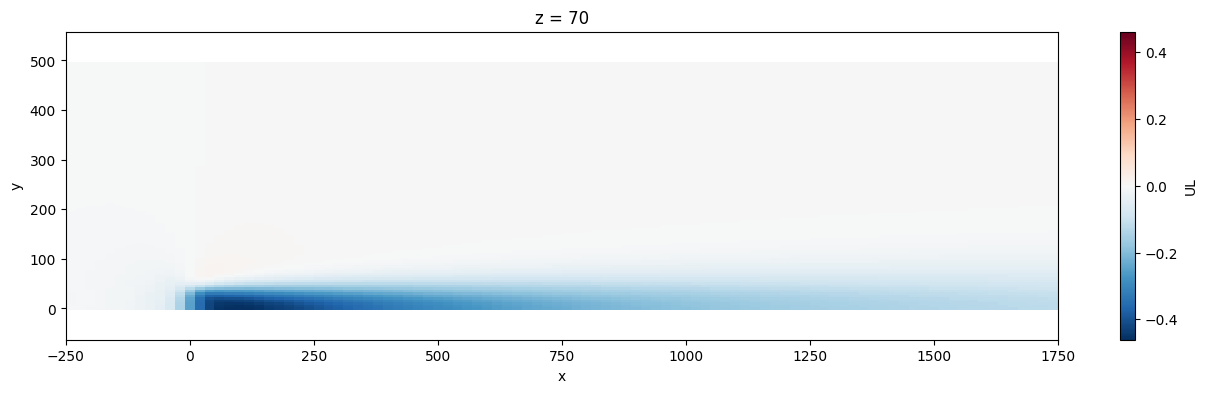

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
luts.UL.squeeze()[500:600, :100].plot(x="x")
plt.axis("equal")

## Wake deficit for different atmospheric-stability conditions

PyFuga can model wake deficits across different atmospheric-stability conditions. This is done by including Monin-Obukhov (MO) theory in the definition of eddy viscosity,

$$
K = \frac{u_\star\kappa z}{\phi(z/L)}
$$

In neutral conditions, $z/L \to 0$ (equivalently, the magnitude of the Obukhov length, $|L|$, is very large), and the eddy viscosity, $K$, varies linearly with height, $z$. It also changes linearly with friction velocity, $u_\star$, linking it to turbulence intensity. The von Kármán constant, $\kappa$, is a universal proportionality constant. In this notebook, we show how, under non-neutral atmospheric conditions, the MO profile function $\phi$ modifies turbulence production, accounting for faster/slower wake recovery under unstable/stable conditions.

There is one important implementation detail. If you run wake calculations through PyWake, the scaling of wake deficits is handled there. If you use LUTs outside PyWake, you need to apply the scaling manually (shown below in the stability-scaling section).

For background theory, see [governing equations](../theory/governing_equations.html) and [linearisation](../theory/linearisation.html).

In [5]:
# Importing the neccessary...
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle

## Stability conditions

Atmospheric stability enters PyFuga through the stability parameter $\xi = z/L$ and, more specifically, through $\xi_0 = z_0/L$, with $z_0$ representing roughness length. In the code and filenames this appears as ```zeta0``` / ```Zeta0```, so here we use them as equivalent labels for $\xi_0$.

This parameter adjusts eddy viscosity through the non-dimensional shear function $\phi(z/L)$. In PyFuga, $\phi(z/L)$ is defined according to Högström (1988),

$$
    \phi_m (z/L) = \begin{cases}
    1+5\frac{z}{L}  & \text{for } \frac{z}{L} \geq 0 \\
    1               & \text{for }  \frac{z}{L} = 0 \\
    (1-19.3\frac{z}{L})^{-1/4} & \text{for } \frac{z}{L} < 0.
    \end{cases}
$$

We create a list of values of $L$ for a specific roughness length $z_0$, so that we can compare how wake deficit changes with stability.

In [6]:
# Obukhov lengths
L_O = np.r_[100, 500]  # Obukhov length
z0 = 1e-4
zeta_0 = np.sort(z0 / L_O)
zeta_0 = np.r_[-zeta_0[::-1], 0, zeta_0]
zeta_0

array([-1.e-06, -2.e-07,  0.e+00,  2.e-07,  1.e-06])

## PyFuga main inputs (apart from stability!)

Other inputs necessary to obtain wake look-up tables (LUTs) are the following:

In [7]:
nkz0 = 8  # Number of kz0 per decade. Total number of kz0 = 9 * nkz0 - (nkz0-1)
nbeta = 16  # Number of beta angles. Total number of beta angles = nbeta + 1
diameter = 80  # Wind turbine diameter [m]
zhub = 70  # Wind turbine hub height [m]
z0 = z0  # Roughness length [m]
zi = 400  # Inversion height [m]
zlow = 70  # Lower height of output domain. If zlow=zhigh=zhub: single layer at hub height
zhigh = 70  # Upper height of output domain. If zlow=zhigh=zhub: single layer at hub height
lut_vars = ["UL"]  # Any combination of ['UL', 'UT', 'VL', 'VT', 'WL', 'WT', 'PL', 'PT']
nx = 2048  # Number of points in LUT (U direction)
ny = 512  # Number of points in LUT (V direction). Note only one half of the domain is stored
dx = 20.0  # Grid resolution of LUT in longitudinal direction x [m]
dy = 5.0  # Grid resolution of LUT in lateral direction y [m]
luts_path = "luts_different_zeta0s_and_nkz0"  # a path where preluts, fourier luts and luts will be stored

The `luts_different_zeta0s` folder will contain the following files, for neutral conditions for instance:
```
preLUTs_Zeta0=0.00_8_16.nc
        └─ Zeta0=0.00   -> Zeta0
                   └─ 8   -> nkz0
                     └─ 16 -> nbeta

fLUTs_Zeta0=0.00_8_16_D80_zhub70_zi400_z0=0.00001000_z70.0_UL.nc
      
                       └─ D80 -> diameter
                            └─ zhub70 -> zhub
                                  └─ zi400 -> zi
                                             └─ z0=0.00001000 -> z0
                                                      └─ z70.0 -> z (output)
                                                          └─ UL -> luts_vars

LUTs_Zeta0=0.00_8_16_D80_zhub70_zi400_z0=0.00001000_z70.0_UL_nx2048_ny512_dx20.0_dy5.0.nc
                                                                └─ nx2048 -> nx
                                                                       └─ ny512 -> ny
                                                                            └─ dx20.0 -> dx
                                                                                  └─ dy5.0 -> dy
```

This naming convention helps clearly identify the inputs used for each file.

## Calculating LUTs for different stability conditions

We now calculate LUTs for the stability conditions defined above. We do this using the ```get_luts``` wrapper function, which creates all required files in the PyFuga pipeline. In this example, we create 5 cases, each with a different stability conditions.

One of the most valuable features of PyFuga is staggered wake estimation. The ```preLUTs``` file (the most computationally expensive stage) only depends on $\xi_0$ (```Zeta0```) and the Fourier-space grid (```nkz0``` and ```nbeta```), so it can be reused for many combinations of later input parameters. ```get_luts``` checks whether previous files already exist in the destination folder and only creates missing pipeline stages.

LUT generation for multiple cases proceeds as follows:

For more detail on the spectral formulation and numerics, see [mixed-spectral formulation](../theory/mixed_spectral.html) and [numerics](../theory/numerics.html).

In [8]:
for zeta_0i in zeta_0:
    luts = get_luts(
        folder=luts_path,  # Path where all files (intermediate and final) are stored
        zeta0=zeta_0i,  # Stability parameter
        nkz0=nkz0,  # Number of kz0 per decade. Total number of kz0 = 9 * nkz0 - (nkz0-1)
        nbeta=nbeta,  # Number of beta angles. Total number of beta angles = nbeta + 1
        diameter=diameter,  # Wind turbine diameter
        zhub=zhub,  # Wind turbine hub height
        z0=z0,  # Roughness length
        zi=zi,  # Inversion height
        zlow=zlow,  # Lower height of output domain. If zlow=zhigh=zhub: single layer at hub height
        zhigh=zhigh,  # Upper height of output domain. If zlow=zhigh=zhub: single layer at hub height
        lut_vars=lut_vars,  # Any combination of ['UL', 'UT', 'VL', 'VT', 'WL', 'WT', 'PL', 'PT']
        nx=nx,  # Number of points in LUT (U direction)
        ny=ny,  # Number of points in LUT (V direction). Note only one half of the domain is stored
        dx=dx,
        dy=dy,  # Distance between points on the x and y axis
        jit=True,  # If True (default), some slow functions are just-in-time compiled
        n_cpu=None,  # Number of CPUs for parallelization, None means all available CPUs
    )

We can retrieve filenames using the naming convention, which we need later in this notebook.

In [9]:
# File names of LUTs, following the naming convention of PyFuga
z_id = f"z{zhub:.1f}"
L_vars = [v[0] for v in lut_vars if v[1] == "L"]
lut_vars_id = ""
lut_vars_id += f"_{''.join(L_vars)}L"
luts_files = []
folder_path = luts_path
for zeta_0i in zeta_0:
    preluts_id = f"Zeta0={zeta_0i:3.2e}_{nkz0}_{nbeta}"
    fluts_id = preluts_id + f"_D{diameter}_zhub{zhub}_zi{zi}_z0={z0:.8f}_{z_id}{lut_vars_id}"
    luts_id = fluts_id + f"_nx{nx}_ny{ny}_dx{dx}_dy{dy}"
    luts_files.append(os.path.join(folder_path, f"LUTs_{luts_id}.nc"))

We now compare how wake deficit changes across different ```Zeta0``` values, so we gather the files we created.

In [10]:
luts_all = {}
file_list = luts_files
for f in file_list:
    lut = xr.load_dataset(f)
    stem = Path(f).stem  # e.g. "LUTs_Zeta0=5.00e-06_16_32_D154_..."
    # find the part that starts with "Zeta0="
    zeta_token = next(part for part in stem.split("_") if part.startswith("Zeta0="))
    # e.g. "Zeta0=5.00e-06"
    # optional: also store the filename as an attribute
    lut.attrs["name"] = stem
    # optional: add a scalar coordinate with the numeric zeta0 inside the dataset
    if "zeta0" in lut.attrs:
        lut = lut.assign_coords(zeta_0=lut.attrs["zeta0"])
    # use the string like "Zeta0=5.00e-06" as the dict key
    luts_all[zeta_token] = lut

luts = list(luts_all.values())

## Stability scaling

There is a very important point to consider about PyFuga output.

- If you run wake calculations through PyWake, this scaling is handled internally.
- If you use LUTs outside PyWake, you must apply the scaling yourself.

The LUT ```NetCDF``` files are stored in a normalised form. To recover dimensional wake deficit ```du``` in speed units, apply

```
du = du_from_luts * c_t * (ws_eff**2)/ws * zeta0_factor

```

Here,

- ```du```: Wake deficit in [m/s]
- ```du_from_luts```: Normalised wake deficit [-]
- ```c_t```: Thrust coefficient [-]
- ```ws_eff```: Effective wind speed at hub height [m/s]
- ```ws```: Free-stream wind speed [m/s]
- ```zeta0_factor```: $U_{\mathrm{non-neutral}}(z, \xi)/U_{\mathrm{neutral}}(z, \xi)$

The neutral velocity profile $U_{\mathrm{neutral}}(z, \xi)$ is defined by the logarithmic profile,

$$
U_{\mathrm{neutral}}(z, \xi) = \frac{u_\star}{\kappa} \log(z/z_0),
$$

and the non-neutral velocity profile $U_{\mathrm{non-neutral}}(z, \xi)$ as,

$$
U_{\mathrm{non-neutral}}(z, \xi) = \frac{u_\star}{\kappa} \left( \log(z/z_0) - (\psi(\xi)-\psi(\xi_0))\right)
$$

with,

$$
\psi(\xi) = \int_{\xi_{0}}^{\xi} \frac{1-\phi(\xi)}{\xi}\,d\xi
$$

from M-O theory.

For theoretical background, see [introduction](../theory/introduction.html) and [governing equations](../theory/governing_equations.html).

We calculate ```zeta0_factor``` with the following helper.


In [11]:
def zeta0_factor(zeta0, zhub, z0):
    invL = zeta0 / z0  # Inverse Obukhov length
    ams = 5  # Högström (1988) for stable conditions (zeta0 >= 0)

    def psim(zeta):
        if zeta0 >= 0:
            return -ams * zeta
        else:
            amu = -19.3  # Högström (1988) for unstable conditions (zeta0 >= 0)
            aux2 = np.sqrt(1 + amu * zeta)
            aux = np.sqrt(aux2)
            return np.pi / 2 - 2 * np.arctan(aux) + np.log((1 + aux) ** 2 * (1 + aux2) / 8)

    return 1 - (psim(zhub * invL) - psim(zeta0)) / np.log(zhub / z0)

We now prepare the LUT data for plotting the normalised and scaled wake deficits side by side, 5 diameters downstream. In practice, we extract hub-height transverse slices at $x=5D$, mirror them to reconstruct the symmetric wake, and then apply ```zeta0_factor``` to obtain the scaled curves used in the comparison.

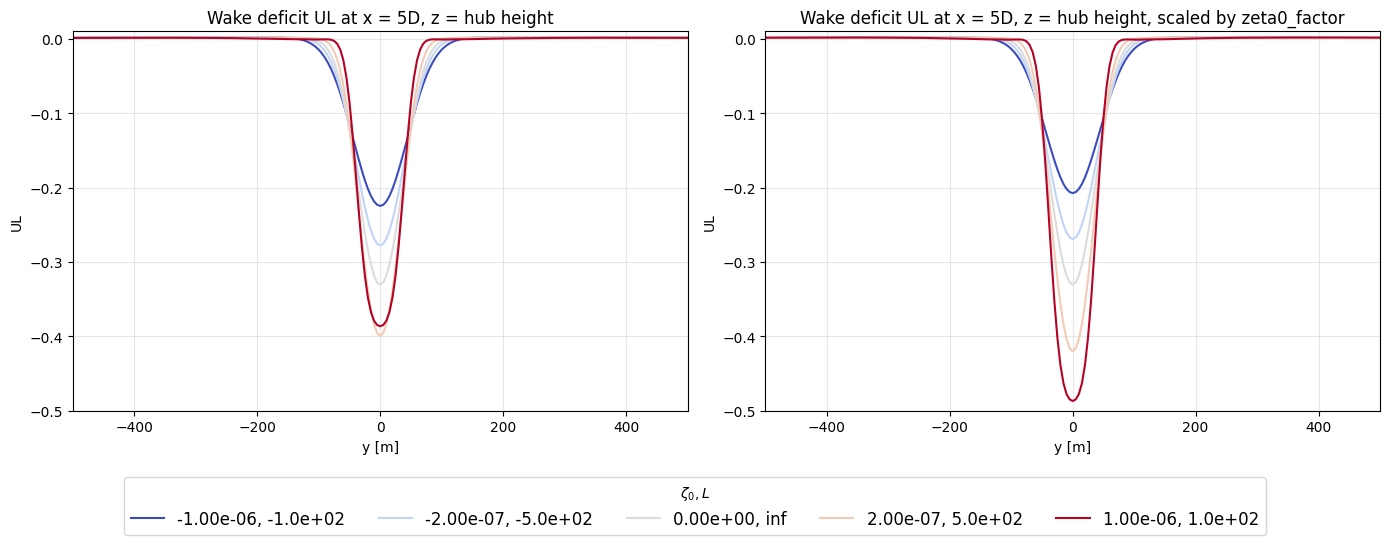

In [12]:
# Extract and sort zeta values
entries = []
for ds in luts:
    zeta = float(ds.coords.get("zeta_0", ds.attrs["zeta0"]))
    L = z0 / zeta if zeta != 0 else np.inf
    entries.append((zeta, ds, L))

entries.sort(key=lambda t: t[0])

# Set up normalization
zeta_vals = [e[0] for e in entries]
norm = TwoSlopeNorm(vmin=min(zeta_vals), vcenter=0.0, vmax=max(zeta_vals))
cmap = plt.get_cmap("coolwarm")

# Create figure
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 5))

# Plot each entry
for zeta, ds, L in entries:
    D = float(ds["diameter"].item())
    ul_5D = ds["UL"].isel(z=0).sel(x=5 * D, method="nearest")
    y = ds["y"].values

    # Create symmetric y and UL arrays
    y_sym = np.concatenate([-y[::-1], y[1:]])
    ul_sym = np.concatenate([ul_5D.values[::-1], ul_5D.values[1:]])

    color = cmap(norm(zeta))
    label = f"{zeta:.2e}, {L:.1e}"

    ax0.plot(y_sym, ul_sym, color=color, label=label)
    ax1.plot(y_sym, ul_sym * zeta0_factor(zeta, zhub, z0), color=color, label=label)

# Configure axes
for ax, title, ylabel in [
    (ax0, "Wake deficit UL at x = 5D, z = hub height", "UL"),
    (ax1, "Wake deficit UL at x = 5D, z = hub height, scaled by zeta0_factor", "UL"),
]:
    ax.set_xlabel("y [m]")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-500, 500)
    ax.set_ylim(-0.5, 0.01)

handles, labels = ax0.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title=r"$\zeta_0, L$",
    loc="upper center",
    bbox_to_anchor=(0.5, 0),
    ncol=max(1, len(labels)),
    fontsize=12,
)

plt.tight_layout(rect=(0, 0, 1, 0.95))

Core quickstart complete – the sections below are more advanced and focus on interpretation and sensitivity.

The deficit above corresponds to scaling by ```zeta0_factor``` only. The remaining scaling factors – wind speed and thrust coefficient – can be applied for different wind conditions, making the resulting LUT reusable for many wind-turbine and wind-farm simulations. One takeaway from this plot is how deficit behaviour changes under non-neutral conditions. Increasingly unstable conditions result in faster wake recovery, while more stable conditions show slower recovery and larger deficits due to reduced turbulence in eddy viscosity $K$. This slower recovery is better visualised in the longitudinal profile at hub height below.

In the Fourier-space solution, this behaviour appears as wake modes shifting towards smaller wavenumbers, so most of the wake corresponds to larger-scale perturbations in the free stream.

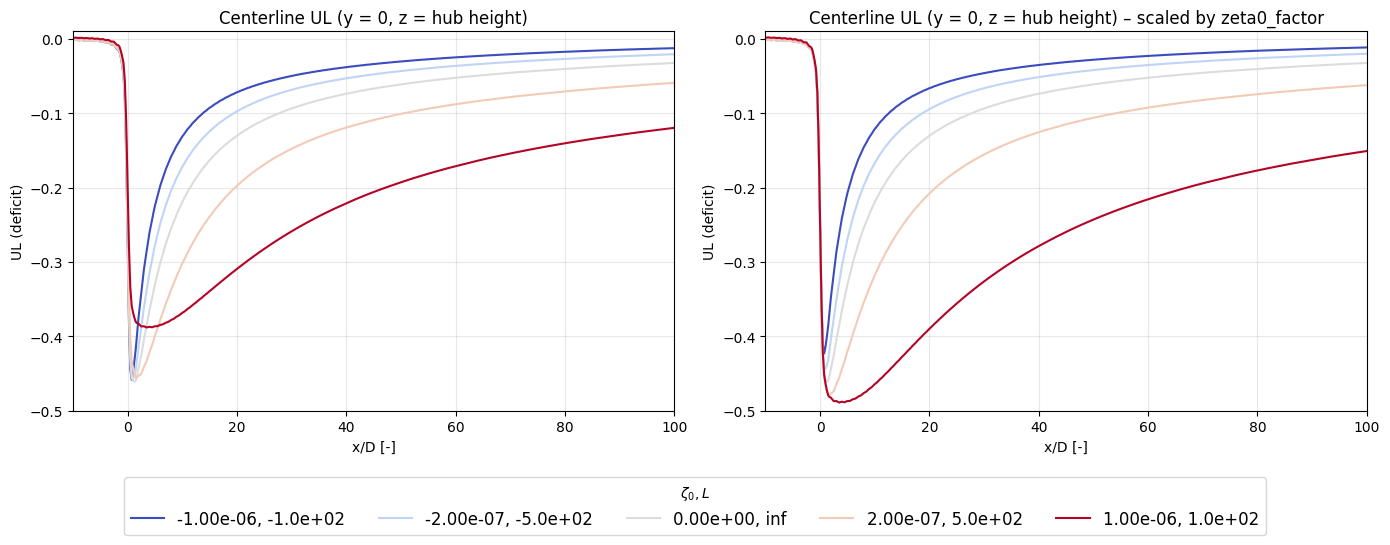

In [13]:
entries = []
for ds in luts:
    zeta = float(ds.coords.get("zeta_0", ds.attrs["zeta0"]))
    L = z0 / zeta if zeta != 0 else np.inf
    entries.append((zeta, ds, L))

entries.sort(key=lambda t: t[0])

zeta_vals = [e[0] for e in entries]
norm = TwoSlopeNorm(vmin=min(zeta_vals), vcenter=0.0, vmax=max(zeta_vals))
cmap = plt.get_cmap("coolwarm")

USE_X_OVER_D = True
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 5))

for zeta, ds, L in entries:
    D = float(ds["diameter"].item())
    ul_center = ds["UL"].isel(z=0).sel(y=0, method="nearest").sortby("x")

    x_plot = (ul_center["x"].values / D) if USE_X_OVER_D else ul_center["x"].values
    ul_vals = ul_center.values
    ul_scaled = ul_vals * zeta0_factor(zeta, zhub, z0)

    color = cmap(norm(zeta))
    label = f"{zeta:.2e}, {L:.1e}"

    ax0.plot(x_plot, ul_vals, color=color, label=label)
    ax1.plot(x_plot, ul_scaled, color=color, label=label)

x_label = "x/D [-]" if USE_X_OVER_D else "x [m]"

for ax, title in [
    (ax0, "Centerline UL (y = 0, z = hub height)"),
    (ax1, "Centerline UL (y = 0, z = hub height) – scaled by zeta0_factor"),
]:
    ax.set_xlabel(x_label)
    ax.set_ylabel("UL (deficit)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-10, 100)
    ax.set_ylim(-0.5, 0.01)

handles, labels = ax0.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title=r"$\zeta_0, L$",
    loc="upper center",
    bbox_to_anchor=(0.5, 0),
    ncol=max(1, len(labels)),
    fontsize=12,
)

plt.tight_layout(rect=(0, 0, 1, 0.95))

# Effects of wavenumber-grid refinement on wake deficit

PyFuga first estimates wake deficit in Fourier space. The resolution of this solution is controlled by the inputs ```nkz0``` and ```nbeta```, corresponding to spectral coordinates $kz_0$ (```kz0```) and $\beta$ (```beta```) in polar representation of the horizontal wavenumber space. Higher resolution and coverage produce larger ```preLUT``` and ```fLUT``` files and therefore slower generation. Lower resolution loses information, which can affect the reconstructed deficit.

Here we check those effects by calculating LUTs under neutral conditions for

- (```nkz0```, ```nbeta```) = (4, 16)
- (```nkz0```, ```nbeta```) = (16, 16)

For more detail, see [mixed-spectral formulation](../theory/mixed_spectral.html) and [numerics](../theory/numerics.html).


In [14]:
nkz0_nbeta = [(4, 16), (8, 16), (16, 16)]  # wavenumber space grid resolutions

for nkz0, nbeta in nkz0_nbeta:
    luts = get_luts(
        folder=luts_path,  # Path where all files (intermediate and final) are stored
        zeta0=0,  # Stability parameter, neutral case
        nkz0=nkz0,  # Number of kz0 per decade. Total number of kz0 = 9 * nkz0 - (nkz0-1)
        nbeta=nbeta,  # Number of beta angles. Total number of beta angles = nbeta + 1
        diameter=diameter,  # Wind turbine diameter
        zhub=zhub,  # Wind turbine hub height
        z0=z0,  # Roughness length
        zi=zi,  # Inversion height
        zlow=zlow,  # Lower height of output domain. If zlow=zhigh=zhub: single layer at hub height
        zhigh=zhigh,  # Upper height of output domain. If zlow=zhigh=zhub: single layer at hub height
        lut_vars=lut_vars,  # Any combination of ['UL', 'UT', 'VL', 'VT', 'WL', 'WT', 'PL', 'PT']
        nx=nx,  # Number of points in LUT (U direction)
        ny=ny,  # Number of points in LUT (V direction). Note only one half of the domain is stored
        dx=dx,
        dy=dy,  # Distance between points on the x and y axis
        jit=True,  # If True (default), some slow functions are just-in-time compiled
        n_cpu=None,  # Number of CPUs for parallelization, None means all available CPUs
    )

In [15]:
# Gathering luts
# File names of LUTs, following the naming convention of PyFuga
zeta0n = 0.0
z_id = f"z{zhub:.1f}"
L_vars = [v[0] for v in lut_vars if v[1] == "L"]
lut_vars_id = ""
lut_vars_id += f"_{''.join(L_vars)}L"
luts_files = []
folder_path = luts_path
for nkz0, nbeta in nkz0_nbeta:
    preluts_id = f"Zeta0={zeta0n:3.2e}_{nkz0}_{nbeta}"
    fluts_id = preluts_id + f"_D{diameter}_zhub{zhub}_zi{zi}_z0={z0:.8f}_{z_id}{lut_vars_id}"
    luts_id = fluts_id + f"_nx{nx}_ny{ny}_dx{dx}_dy{dy}"
    luts_files.append(os.path.join(folder_path, f"LUTs_{luts_id}.nc"))

In [16]:
luts_all_nkz0 = {}
for f in luts_files:
    stem = Path(f).stem
    parts = stem.split("_")
    zeta_token = next((p for p in parts if p.startswith("Zeta0=")), None)
    if zeta_token != "Zeta0=0.00e+00":
        continue
    # nkz0 and nbeta are the two entries after Zeta0=...
    i = parts.index(zeta_token)
    nkz0n = int(parts[i + 1])
    nbetan = int(parts[i + 2])
    case = (nkz0n, nbetan)
    if case not in nkz0_nbeta:
        continue
    lut = xr.load_dataset(f)
    lut.attrs["name"] = stem
    lut.attrs["nkz0"] = nkz0
    lut.attrs["nbeta"] = nbeta

    luts_all_nkz0[case] = lut
luts_nkz0 = list(luts_all_nkz0.values())

Now we plot wake deficits for different (```nkz0```, ```nbeta```) combinations.

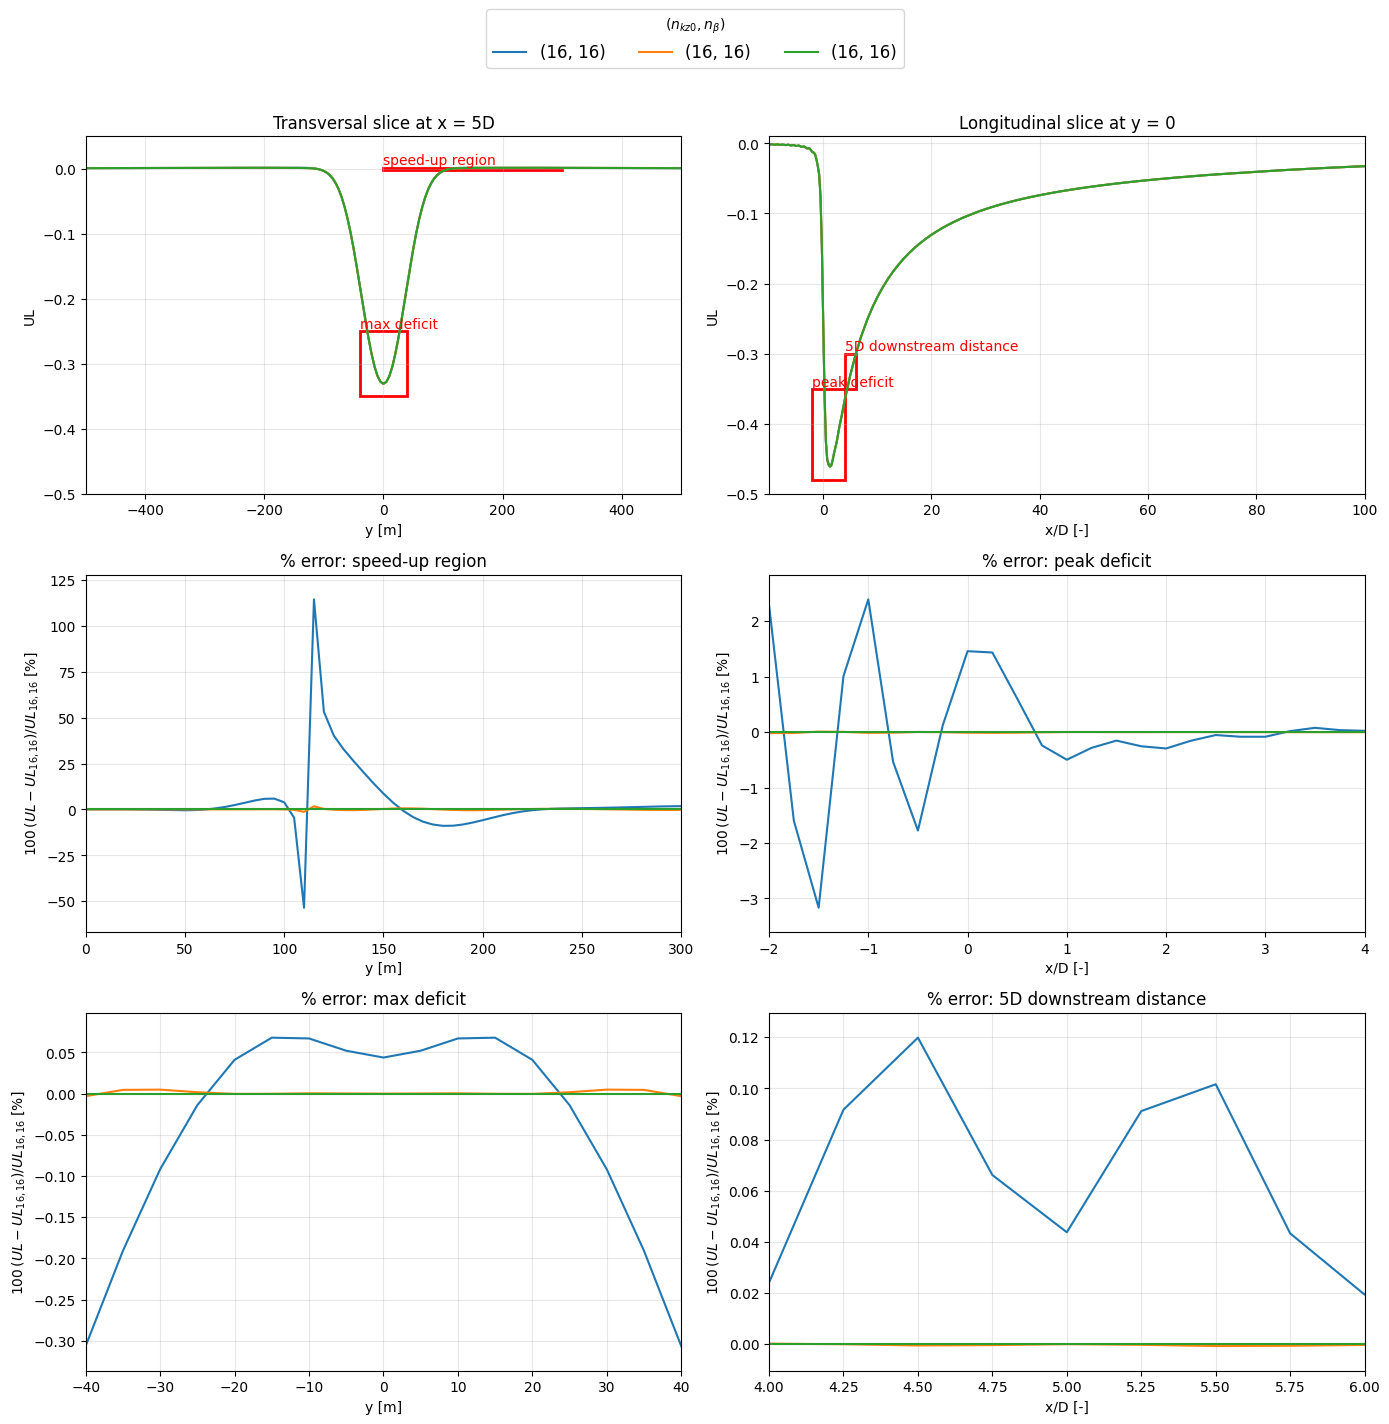

In [17]:
# ---------------------------------
# plot setup
# ---------------------------------
xlim_t = (-500, 500)
ylim_t = (-0.5, 0.05)
xlim_l = (-10, 100)
ylim_l = (-0.5, 0.01)
zoom1_x_t, zoom1_y_t = (0, 300), (-0.001, 0.002)
zoom2_x_t, zoom2_y_t = (-40, 40), (-0.35, -0.25)
zoom1_x_l, zoom1_y_l = (-2, 4), (-0.48, -0.35)
zoom2_x_l, zoom2_y_l = (4, 6), (-0.35, -0.3)
lab_z1_t, lab_z2_t = "speed-up region", "max deficit"
lab_z1_l, lab_z2_l = "peak deficit", "5D downstream distance"
highlight_color = "red"
# ---------------------------------
# reference profiles
# ---------------------------------
field = "UL"
eps = 1e-12
x_over_D = 5
ref_case = (16, 16)
ds_ref = luts_all_nkz0[ref_case]
D_ref = float(ds_ref["diameter"].item())
A_ref = ds_ref[field].isel(z=0)
v_t_ref = A_ref.sel(x=x_over_D * D_ref, method="nearest").values
y_ref = ds_ref["y"].values
y_ref_sym = np.concatenate([-y_ref[::-1], y_ref[1:]])
v_t_ref_sym = np.concatenate([v_t_ref[::-1], v_t_ref[1:]])
prof_l_ref = A_ref.sel(y=0, method="nearest").sortby("x")
x_ref = prof_l_ref["x"].values / D_ref
v_l_ref = prof_l_ref.values


# ---------------------------------
# extract curves
# ---------------------------------
def extract_curve(ds, field, z_index, x_over_D, y_ref_sym, x_ref, v_t_ref_sym, v_l_ref, eps):
    D = float(ds["diameter"].item())
    A = ds[field].isel(z=z_index)

    v_t = A.sel(x=x_over_D * D, method="nearest").values
    y = ds["y"].values
    y_sym = np.concatenate([-y[::-1], y[1:]])
    v_t_sym = np.concatenate([v_t[::-1], v_t[1:]])
    v_t_on_ref = np.interp(y_ref_sym, y_sym, v_t_sym)
    err_t = np.where(
        np.abs(v_t_ref_sym) > eps,
        100 * (v_t_on_ref - v_t_ref_sym) / v_t_ref_sym,
        np.nan,
    )

    prof_l = A.sel(y=0, method="nearest").sortby("x")
    x_plot = prof_l["x"].values / D
    v_l = prof_l.values
    v_l_on_ref = np.interp(x_ref, x_plot, v_l)
    err_l = np.where(np.abs(v_l_ref) > eps, 100 * (v_l_on_ref - v_l_ref) / v_l_ref, np.nan)

    return {
        "label": str((ds.attrs["nkz0"], ds.attrs["nbeta"])),
        "y_t": y_sym,
        "v_t": v_t_sym,
        "x_l": x_plot,
        "v_l": v_l,
        "y_ref": y_ref_sym,
        "err_t": err_t,
        "x_ref": x_ref,
        "err_l": err_l,
    }


curves = [extract_curve(ds, field, 0, x_over_D, y_ref_sym, x_ref, v_t_ref_sym, v_l_ref, eps) for ds in luts_nkz0]


# ---------------------------------
# compute error limits
# ---------------------------------
def ylim_from_region(x, y, xlim, pad=0.08):
    m = (x >= xlim[0]) & (x <= xlim[1]) & np.isfinite(y)
    if not np.any(m):
        return (-1, 1)
    ymin, ymax = np.nanmin(y[m]), np.nanmax(y[m])
    d = max(abs(ymin), 1.0) * 0.1 if np.isclose(ymin, ymax) else pad * (ymax - ymin)
    return ymin - d, ymax + d


err_t_all = np.concatenate([c["err_t"] for c in curves])
err_l_all = np.concatenate([c["err_l"] for c in curves])
y_ref_all = np.concatenate([c["y_ref"] for c in curves])
x_ref_all = np.concatenate([c["x_ref"] for c in curves])
ylim_err_t1 = ylim_from_region(y_ref_all, err_t_all, zoom1_x_t)
ylim_err_t2 = ylim_from_region(y_ref_all, err_t_all, zoom2_x_t)
ylim_err_l1 = ylim_from_region(x_ref_all, err_l_all, zoom1_x_l)
ylim_err_l2 = ylim_from_region(x_ref_all, err_l_all, zoom2_x_l)
# ---------------------------------
# plot
# ---------------------------------
fig, ax = plt.subplots(3, 2, figsize=(14, 14))
for c in curves:
    ax[0, 0].plot(c["y_t"], c["v_t"], label=c["label"])
    ax[0, 1].plot(c["x_l"], c["v_l"], label=c["label"])
    for row in [1, 2]:
        ax[row, 0].plot(c["y_ref"], c["err_t"], label=c["label"])
        ax[row, 1].plot(c["x_ref"], c["err_l"], label=c["label"])
err_label = (
    rf"$100\,({field}-{field}_{{{ref_case[0]},{ref_case[1]}}})/" rf"{field}_{{{ref_case[0]},{ref_case[1]}}}$ [%]"
)
subplots = [
    ((0, 0), f"Transversal slice at x = {x_over_D}D", "y [m]", field, xlim_t, ylim_t),
    ((0, 1), "Longitudinal slice at y = 0", "x/D [-]", field, xlim_l, ylim_l),
    ((1, 0), f"% error: {lab_z1_t}", "y [m]", err_label, zoom1_x_t, ylim_err_t1),
    ((1, 1), f"% error: {lab_z1_l}", "x/D [-]", err_label, zoom1_x_l, ylim_err_l1),
    ((2, 0), f"% error: {lab_z2_t}", "y [m]", err_label, zoom2_x_t, ylim_err_t2),
    ((2, 1), f"% error: {lab_z2_l}", "x/D [-]", err_label, zoom2_x_l, ylim_err_l2),
]
for (row, col), title, xlabel, ylabel, xlim, ylim in subplots:
    a = ax[row, col]
    a.set_title(title)
    a.set_xlabel(xlabel)
    a.set_ylabel(ylabel)
    a.set_xlim(*xlim)
    a.set_ylim(*ylim)
    a.grid(True, alpha=0.3)
for xlim, ylim, label in [
    (zoom1_x_t, zoom1_y_t, lab_z1_t),
    (zoom2_x_t, zoom2_y_t, lab_z2_t),
]:
    rect = Rectangle(
        (xlim[0], ylim[0]),
        xlim[1] - xlim[0],
        ylim[1] - ylim[0],
        fill=False,
        edgecolor=highlight_color,
        linewidth=2,
    )
    ax[0, 0].add_patch(rect)
    ax[0, 0].text(xlim[0], ylim[1], label, color=highlight_color, fontsize=10, va="bottom")
for xlim, ylim, label in [
    (zoom1_x_l, zoom1_y_l, lab_z1_l),
    (zoom2_x_l, zoom2_y_l, lab_z2_l),
]:
    rect = Rectangle(
        (xlim[0], ylim[0]),
        xlim[1] - xlim[0],
        ylim[1] - ylim[0],
        fill=False,
        edgecolor=highlight_color,
        linewidth=2,
    )
    ax[0, 1].add_patch(rect)
    ax[0, 1].text(xlim[0], ylim[1], label, color=highlight_color, fontsize=10, va="bottom")

handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title=r"$(n_{kz0}, n_\beta)$",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=max(1, len(labels)),
    fontsize=12,
)
plt.tight_layout(rect=(0, 0, 1, 0.95))

Selecting a small ```nkz0``` significantly accelerates LUT generation, but it also affects deficit estimation, especially in speed-up regions. This can generate spurious effects if blockage is included in a wind-farm simulation. The absolute error is generally small, and in the area of maximum deficit it is very small. For this setup, we recommend using ```nkz0 = 8``` to balance speed and accuracy/smoothness.

## Takeaways from this example notebook

- PyFuga can model non-neutral conditions: wake deficits under stable conditions persist over much longer distances and show larger deficits relative to inflow wind speed. To obtain the dimensional non-neutral wake deficit outside PyWake, scale using hub-height inflow wind speed, thrust coefficient, and ```zeta0_factor```.

- ```nkz0``` matters: too little wavenumber refinement causes visible wriggles in wake speed-up regions. For this setup, ```nkz0 = 8``` gives a good balance between speed and smoothness.

- For theory and derivation details, see the [theory introduction](../theory/introduction.html), [mixed-spectral formulation](../theory/mixed_spectral.html), and [numerical solution](../theory/numerics.html).